# 06 — Final evaluation on the untouched test set (2023–2024)

**Scope (Phase B, final report).** The six frozen models — persistence, day-of-year
climatology, DHR, random forest, XGBoost, and LSTM — are refit on **2005–2022**
(training + validation) using the configurations selected in notebooks 04–05, then
evaluated **once** on the untouched **2023–2024** test window, per site and per
horizon (1-day, 7-day). This notebook also runs the committed inference: one-sided
HLN-corrected Diebold–Mariano tests with Holm adjustment and moving-block-bootstrap
skill intervals (RQ1/H1), SHAP predictor-importance and correlation testing
(RQ2/H2), and formal seasonal and zonal error tests (RQ3/H3). Reproducibility:
`SEED = 42` throughout; every expensive step is checkpointed to
`results/cache/nb06/` (resumable; optional `NB06_BUDGET_S` wall-clock budget).

**Protocol discipline.** No model, hyperparameter, or feature choice is revisited
here: hyperparameters come from `ml_best_params.json` (notebook 05), the "best ML
model" used in the key comparisons was frozen per site and horizon on 2021–2022
**validation** RMSE before the test window was opened, and the 2023–2024 window is
scored exactly once. All predictions are indexed by **target date** so the six
models are compared on identical days.

In [1]:
import os, sys, json, time, random, pickle, warnings
sys.path.append('../src')
warnings.filterwarnings('ignore')
os.environ.setdefault('PYTHONHASHSEED', '42')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import (SITES, PARAMETERS, DATA_PROCESSED, RESULTS, TRAIN_END, VAL_END)

SEED = 42                      # fixed project-wide seed (used in every notebook)
random.seed(SEED)
np.random.seed(SEED)

TARGET = 'ALLSKY_SFC_SW_DWN'
HORIZONS = [1, 7]
B_BOOT = 2000                  # bootstrap replicates (moving-block)
FIGDIR = RESULTS / 'figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

# --- Optional execution budget (same machinery as notebook 05) --------------
# NB06_BUDGET_S (optional): wall-clock seconds this run may spend on the
# expensive steps; once spent, the run aborts cleanly and a rerun resumes from
# results/cache/nb06/.
BUDGET_S = float(os.environ['NB06_BUDGET_S']) if os.environ.get('NB06_BUDGET_S') else None
RUN_T0 = time.time()

CACHE = RESULTS / 'cache' / 'nb06'
CACHE.mkdir(parents=True, exist_ok=True)

class BudgetExhausted(RuntimeError):
    """Raised when NB06_BUDGET_S is used up; rerun the notebook to resume."""

def budget_left():
    return None if BUDGET_S is None else BUDGET_S - (time.time() - RUN_T0)

def require_budget(seconds_needed):
    left = budget_left()
    if left is not None and left < seconds_needed:
        raise BudgetExhausted(
            f'{left:.0f}s of budget left (<{seconds_needed}s needed); '
            'rerun the notebook to resume from results/cache/nb06/.')

# Cache entries are plain dicts (version-portable across pandas/numpy).
def _pack_series(s):
    return {'dates': s.index.strftime('%Y-%m-%d').tolist(),
            'values': [float(v) for v in s.to_numpy()]}

def _unpack_series(d):
    return pd.Series(d['values'], index=pd.to_datetime(d['dates']))

SITE_ORDER = ['navrongo', 'tamale', 'kumasi', 'accra', 'takoradi']
SITE_COLOR = {'navrongo': '#D55E00', 'tamale': '#0072B2', 'kumasi': '#009E73',
              'accra': '#E69F00', 'takoradi': '#CC79A7'}
SITE_LABEL = {k: SITES[k]['name'] for k in SITES}

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True})

print('Budget:', f'{BUDGET_S:.0f}s' if BUDGET_S else 'none')

Budget: none


## 6.1 Data, splits, and alignment

Features and leakage discipline are identical to notebook 05 (all predictors known
at the forecast origin *t*; direct strategy per horizon). Refit window: 2005–2022.
Test window: 2023–2024 (731 days per site; the first *h* target days lack a
same-window origin under the direct strategy, so N = 731 − h per site after
alignment across models).

In [2]:
df = pd.read_csv(DATA_PROCESSED / 'all_sites_daily.csv', parse_dates=['date'])
df = df.set_index('date')
refit_end = pd.Timestamp(VAL_END)          # models refit on 2005-2022
test_end = df.index.max()                  # test window: 2023-2024

MET = ['T2M', 'RH2M', 'CLOUD_AMT', 'PRECTOTCORR', 'WS2M']
FEATURES = ([TARGET]                                  # today's GHI (lag 0 w.r.t. origin)
            + [f'ghi_lag{l}' for l in range(1, 7)]    # y_{t-1} ... y_{t-6}
            + ['ghi_roll7', 'ghi_roll30']             # rolling means up to t
            + MET                                     # today's weather
            + ['doy_sin', 'doy_cos'])                 # calendar position

def make_xy(site_df, horizon=1):
    X = site_df[FEATURES].copy()
    y = site_df[TARGET].shift(-horizon)               # target = GHI at t + h
    ok = X.notna().all(axis=1) & y.notna()
    return X[ok], y[ok]

def metrics(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    rmse = float(np.sqrt(np.mean((y - yhat) ** 2)))
    mae = float(np.mean(np.abs(y - yhat)))
    r2 = float(1 - np.sum((y - yhat) ** 2) / np.sum((y - y.mean()) ** 2))
    return rmse, mae, r2

WET = {'major_wet', 'minor_wet'}
DRY = {'harmattan_dry', 'minor_dry'}
ZONE = {k: df.loc[df['site'] == k, 'zone'].iloc[0] for k in SITE_ORDER}

# Frozen configurations from notebook 05 (validation-selected; '_meta' skipped)
with open(RESULTS / 'ml_best_params.json') as fh:
    bp_raw = json.load(fh)
BEST_PARAMS = {k: v for k, v in bp_raw.items() if not k.startswith('_')}
RF_TREES = bp_raw.get('_meta', {}).get('rf_n_estimators', 500)

# Best ML model per site & horizon, frozen on 2021-2022 validation RMSE (NB05)
val_ml = pd.concat([pd.read_csv(RESULTS / f'ml_{h}day_metrics.csv') for h in HORIZONS])
LBL2KEY = {v: k for k, v in SITE_LABEL.items()}
BEST_ML = {}
for h in HORIZONS:
    sub = val_ml[val_ml['Horizon'] == f'{h}-day']
    for lbl, g in sub.groupby('Site'):
        BEST_ML[(LBL2KEY[lbl], h)] = g.loc[g['RMSE'].idxmin(), 'Model']
print('search mode of frozen params:', bp_raw.get('_meta', {}).get('search_mode'))
print('validation-frozen best ML per (site, horizon):')
print({f'{s}|{h}d': m for (s, h), m in BEST_ML.items()})
print(f'test window: {refit_end.date()} < target <= {test_end.date()}')

search mode of frozen params: full
validation-frozen best ML per (site, horizon):
{'accra|1d': 'Random forest', 'kumasi|1d': 'Random forest', 'navrongo|1d': 'LSTM', 'takoradi|1d': 'XGBoost', 'tamale|1d': 'Random forest', 'accra|7d': 'Random forest', 'kumasi|7d': 'Random forest', 'navrongo|7d': 'Random forest', 'takoradi|7d': 'LSTM', 'tamale|7d': 'LSTM'}
test window: 2022-12-31 < target <= 2024-12-31


## 6.2 Classical baselines, refit through 2022

Persistence needs no fitting. Climatology is the 2005–2022 day-of-year mean. DHR
(K = 3 annual Fourier harmonics + AR(1) errors, as in notebook 04) is re-estimated
per site on 2005–2022; the *h*-step forecast is the seasonal mean plus
$\hat\phi^{\,h}$ times the origin-day anomaly.

In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fourier_X(index, K=3):
    doy = index.dayofyear.values
    cols = {'const': np.ones(len(index))}
    for k in range(1, K + 1):
        cols[f'sin{k}'] = np.sin(2 * np.pi * k * doy / 365.25)
        cols[f'cos{k}'] = np.cos(2 * np.pi * k * doy / 365.25)
    return pd.DataFrame(cols, index=index)

# preds[(site, h)] -> dict model -> Series indexed by TARGET date (test window)
preds = {}
dhr_refit = {}

for key in SITE_ORDER:
    cpath = CACHE / f'base_{key}.pkl'
    if cpath.exists():
        with open(cpath, 'rb') as fh:
            unit = pickle.load(fh)
    else:
        require_budget(40)
        t0 = time.time()
        y = df.loc[df['site'] == key, TARGET].dropna()
        y_fit = y[y.index <= refit_end]                       # 2005-2022
        X_full = fourier_X(y.index)
        mod = SARIMAX(y_fit, exog=fourier_X(y_fit.index), order=(1, 0, 0), trend='n')
        res = mod.fit(disp=False)
        phi = float(res.params['ar.L1'])
        beta = res.params[X_full.columns]
        mu = pd.Series(X_full.values @ beta.values, index=y.index)
        e = y - mu
        clim = y_fit.groupby(y_fit.index.dayofyear).mean()
        unit = {'dhr': {'phi': round(phi, 3),
                        'sigma2': round(float(res.params['sigma2']), 4),
                        'aic': round(float(res.aic), 1)},
                'train_s': None, 'preds': {}}
        for h in HORIZONS:
            target_dates = y.index[(y.index > refit_end) & (y.index <= test_end)]
            origin = target_dates - pd.Timedelta(days=h)
            p = pd.DataFrame(index=target_dates)
            p['Persistence'] = y.reindex(origin).values
            p['Climatology'] = clim.reindex(target_dates.dayofyear).values
            p['DHR'] = mu[target_dates].values + phi ** h * e.reindex(origin).values
            unit['preds'][h] = {m: _pack_series(p[m].dropna())
                                for m in ('Persistence', 'Climatology', 'DHR')}
        unit['train_s'] = round(time.time() - t0, 1)
        with open(cpath, 'wb') as fh:
            pickle.dump(unit, fh)
    dhr_refit[key] = unit['dhr']
    for h in HORIZONS:
        d = preds.setdefault((key, h), {})
        for m, packed in unit['preds'][h].items():
            d[m] = _unpack_series(packed)

print('DHR refit (2005-2022) parameters per site:', dhr_refit)

DHR refit (2005-2022) parameters per site: {'navrongo': {'phi': 0.168, 'sigma2': 0.8696, 'aic': 17755.8}, 'tamale': {'phi': 0.151, 'sigma2': 0.7457, 'aic': 16745.2}, 'kumasi': {'phi': 0.214, 'sigma2': 0.429, 'aic': 13109.6}, 'accra': {'phi': 0.16, 'sigma2': 0.7211, 'aic': 16524.5}, 'takoradi': {'phi': 0.231, 'sigma2': 1.0165, 'aic': 18781.8}}


## 6.3 Machine-learning models, refit through 2022

Each site × horizon random forest and XGBoost is refit on 2005–2022 with its
notebook-05 configuration. The LSTM is refit with its selected architecture for its
selected epoch count (scaler re-fit on 2005–2022 rows only; windows ending in the
test period are scored). Refits are checkpointed and timed like notebook 05.

In [4]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

UNIT_COST_S = {'Random forest': 90, 'XGBoost': 25}
refit_times = []

def tree_estimator(model_name, params):
    if model_name == 'Random forest':
        return RandomForestRegressor(n_estimators=RF_TREES, random_state=SEED,
                                     n_jobs=-1, **params)
    return XGBRegressor(n_estimators=800, objective='reg:squarederror',
                        random_state=SEED, n_jobs=-1, verbosity=0, **params)

for h in HORIZONS:
    for key in SITE_ORDER:
        sdf = df[df['site'] == key]
        X, y = make_xy(sdf, horizon=h)
        fit_m = X.index <= refit_end
        test_m = X.index > refit_end
        for model_name in ('Random forest', 'XGBoost'):
            cpath = CACHE / f"tree_{key}_{model_name.replace(' ', '')}_{h}d.pkl"
            if cpath.exists():
                with open(cpath, 'rb') as fh:
                    unit = pickle.load(fh)
            else:
                require_budget(UNIT_COST_S[model_name])
                est = tree_estimator(model_name,
                                     BEST_PARAMS[f'{key}|{model_name}|{h}-day'])
                t0 = time.time()
                est.fit(X[fit_m], y[fit_m])
                train_s = round(time.time() - t0, 1)
                yhat = pd.Series(est.predict(X[test_m]),
                                 index=X.index[test_m] + pd.Timedelta(days=h))
                unit = {'pred': _pack_series(yhat), 'train_s': train_s,
                        'train_s_src': 'measured'}
                with open(cpath, 'wb') as fh:
                    pickle.dump(unit, fh)
            preds[(key, h)][model_name] = _unpack_series(unit['pred'])
            refit_times.append({'Site': SITE_LABEL[key], 'Model': model_name,
                                'Horizon': f'{h}-day',
                                'Refit_s': unit.get('train_s')})
        print(f'{SITE_LABEL[key]:<9} {h}-day tree refits done')

Navrongo  1-day tree refits done
Tamale    1-day tree refits done
Kumasi    1-day tree refits done
Accra     1-day tree refits done
Takoradi  1-day tree refits done
Navrongo  7-day tree refits done


Tamale    7-day tree refits done
Kumasi    7-day tree refits done
Accra     7-day tree refits done
Takoradi  7-day tree refits done


### LSTM refits

Epoch-by-epoch training with on-disk checkpoints (no early stopping here — the
epoch count was selected in notebook 05), `keras.utils.set_random_seed(SEED)` per
refit.

In [5]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from numpy.lib.stride_tricks import sliding_window_view

tf.get_logger().setLevel('ERROR')
WINDOW, BATCH = 30, 64

def build_lstm(n_features, units, n_layers, dropout):
    model = keras.Sequential()
    model.add(keras.Input(shape=(WINDOW, n_features)))
    for i in range(n_layers):
        model.add(keras.layers.LSTM(units, return_sequences=(i < n_layers - 1)))
        if dropout > 0:
            model.add(keras.layers.Dropout(dropout))
    model.add(keras.layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    return model

def refit_checkpointed(tag, n_features, cfg, X_fit, y_fit, n_epochs):
    """Fixed-epoch refit with resumable on-disk checkpoints (as notebook 05)."""
    sdir = CACHE / f'lstm_{tag}'
    sdir.mkdir(exist_ok=True)
    sfile, mfile = sdir / 'state.json', sdir / 'model.keras'
    if sfile.exists():
        with open(sfile) as fh:
            state = json.load(fh)
        if state['done']:
            return state
        model = keras.models.load_model(mfile)
        keras.utils.set_random_seed(SEED + state['epoch'])
    else:
        keras.utils.set_random_seed(SEED)
        model = build_lstm(n_features, **cfg)
        state = {'cfg': cfg, 'epoch': 0, 'train_s': 0.0, 'done': False}
    while state['epoch'] < n_epochs:
        try:
            require_budget(20)
        except BudgetExhausted:
            model.save(mfile)
            with open(sfile, 'w') as fh:
                json.dump(state, fh)
            raise
        t0 = time.time()
        model.fit(X_fit, y_fit, epochs=1, batch_size=BATCH, verbose=0)
        state['train_s'] = round(state.get('train_s', 0.0) + time.time() - t0, 1)
        state['epoch'] += 1
    state['done'] = True
    model.save(mfile)
    with open(sfile, 'w') as fh:
        json.dump(state, fh)
    return state

for h in HORIZONS:
    for key in SITE_ORDER:
        fpath = CACHE / f'lstm_final_{key}_{h}d.pkl'
        if not fpath.exists():
            cfg_all = BEST_PARAMS[f'{key}|LSTM|{h}-day']
            cfg = {k: cfg_all[k] for k in ('units', 'n_layers', 'dropout')}
            n_epochs = int(cfg_all['best_epoch'])

            sdf = df[df['site'] == key].sort_index()
            X_all = sdf[FEATURES]
            y_all = sdf[TARGET].shift(-h)
            ok = X_all.notna().all(axis=1)
            X_all, y_all = X_all[ok], y_all[ok]
            dates = X_all.index

            scaler = StandardScaler().fit(X_all[dates <= refit_end])
            Xs = scaler.transform(X_all).astype('float32')
            W = sliding_window_view(Xs, (WINDOW, Xs.shape[1])).squeeze(axis=1)
            end_dates = dates[WINDOW - 1:]
            yW = y_all.iloc[WINDOW - 1:].to_numpy(dtype='float32')
            keep = ~np.isnan(yW)
            W, end_dates, yW = W[keep], end_dates[keep], yW[keep]
            fit_m = end_dates <= refit_end
            test_m = end_dates > refit_end

            st = refit_checkpointed(f'{key}_{h}d', W.shape[2], cfg,
                                    W[fit_m], yW[fit_m], n_epochs)
            model = keras.models.load_model(CACHE / f'lstm_{key}_{h}d' / 'model.keras')
            yhat = pd.Series(model.predict(W[test_m], verbose=0).ravel(),
                             index=end_dates[test_m] + pd.Timedelta(days=h))
            unit = {'pred': _pack_series(yhat), 'cfg': cfg_all,
                    'train_s': st.get('train_s'), 'train_s_src': 'measured'}
            with open(fpath, 'wb') as fh:
                pickle.dump(unit, fh)
        with open(fpath, 'rb') as fh:
            unit = pickle.load(fh)
        preds[(key, h)]['LSTM'] = _unpack_series(unit['pred'])
        refit_times.append({'Site': SITE_LABEL[key], 'Model': 'LSTM',
                            'Horizon': f'{h}-day', 'Refit_s': unit.get('train_s')})
        print(f"{SITE_LABEL[key]:<9} {h}-day LSTM refit done "
              f"(cfg={unit['cfg']}, {unit.get('train_s', float('nan'))}s)")

pd.DataFrame(refit_times).to_csv(RESULTS / 'nb06_refit_times.csv', index=False)

Navrongo  1-day LSTM refit done (cfg={'units': 64, 'n_layers': 2, 'dropout': 0.2, 'best_epoch': 15}, 54.5s)
Tamale    1-day LSTM refit done (cfg={'units': 128, 'n_layers': 2, 'dropout': 0.2, 'best_epoch': 15}, 92.7s)
Kumasi    1-day LSTM refit done (cfg={'units': 32, 'n_layers': 2, 'dropout': 0.2, 'best_epoch': 36}, 45.3s)
Accra     1-day LSTM refit done (cfg={'units': 128, 'n_layers': 2, 'dropout': 0.2, 'best_epoch': 7}, 66.3s)
Takoradi  1-day LSTM refit done (cfg={'units': 64, 'n_layers': 2, 'dropout': 0.2, 'best_epoch': 7}, 26.5s)
Navrongo  7-day LSTM refit done (cfg={'units': 32, 'n_layers': 1, 'dropout': 0.2, 'best_epoch': 16}, 9.6s)
Tamale    7-day LSTM refit done (cfg={'units': 128, 'n_layers': 1, 'dropout': 0.2, 'best_epoch': 12}, 28.9s)
Kumasi    7-day LSTM refit done (cfg={'units': 32, 'n_layers': 2, 'dropout': 0.0, 'best_epoch': 21}, 25.8s)
Accra     7-day LSTM refit done (cfg={'units': 32, 'n_layers': 2, 'dropout': 0.2, 'best_epoch': 6}, 8.0s)
Takoradi  7-day LSTM refit don

## 6.4 Test-set results: the single evaluation

Metrics per site, model, and horizon on the aligned 2023–2024 target days: RMSE,
MAE, R², plus skill (percentage RMSE reduction) versus DHR, climatology, and
persistence. Saved to `test_metrics.csv`, `test_skill.csv`, and
`test_predictions.csv` (consumed again by notebook 07's sizing simulation).

In [6]:
MODELS = ['Persistence', 'Climatology', 'DHR', 'Random forest', 'XGBoost', 'LSTM']

# align all six models on common target dates; attach actuals
aligned = {}          # (site, h) -> DataFrame [actual + 6 model columns]
met_rows, pred_rows = [], []
for h in HORIZONS:
    for key in SITE_ORDER:
        y = df.loc[df['site'] == key, TARGET]
        p = pd.DataFrame(preds[(key, h)])
        p = p.dropna()                                  # common target dates
        p.insert(0, 'actual', y.reindex(p.index))
        p = p.dropna(subset=['actual'])
        aligned[(key, h)] = p
        for m in MODELS:
            rmse, mae, r2 = metrics(p['actual'], p[m])
            met_rows.append({'Site': SITE_LABEL[key], 'Horizon': f'{h}-day',
                             'Model': m, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
                             'N': len(p)})
            pred_rows.append(pd.DataFrame({'date': p.index, 'site': key,
                                           'model': m, 'horizon': f'{h}-day',
                                           'yhat': p[m].values}))

test_met = pd.DataFrame(met_rows).round(3)
test_met.to_csv(RESULTS / 'test_metrics.csv', index=False)
pd.concat(pred_rows).to_csv(RESULTS / 'test_predictions.csv', index=False)

# skill vs each classical reference
sk = test_met.pivot_table(index=['Site', 'Horizon'], columns='Model', values='RMSE')
skill_rows = []
for (site, hz), r in sk.iterrows():
    for m in ('Random forest', 'XGBoost', 'LSTM'):
        skill_rows.append({'Site': site, 'Horizon': hz, 'Model': m,
                           'RMSE': r[m],
                           'Skill vs DHR (%)': round(100 * (r['DHR'] - r[m]) / r['DHR'], 1),
                           'Skill vs Climatology (%)': round(100 * (r['Climatology'] - r[m]) / r['Climatology'], 1),
                           'Skill vs Persistence (%)': round(100 * (r['Persistence'] - r[m]) / r['Persistence'], 1)})
test_skill = pd.DataFrame(skill_rows)
test_skill.to_csv(RESULTS / 'test_skill.csv', index=False)

print('Test RMSE (kWh/m²/day), 2023-2024:')
print(test_met.pivot_table(index=['Horizon', 'Model'], columns='Site',
                           values='RMSE').round(3).loc[
      [(f'{h}-day', m) for h in HORIZONS for m in MODELS]])
test_skill[test_skill['Horizon'] == '1-day']

Test RMSE (kWh/m²/day), 2023-2024:
Site                   Accra  Kumasi  Navrongo  Takoradi  Tamale
Horizon Model                                                   
1-day   Persistence    1.208   0.908     1.108     1.373   1.130
        Climatology    0.926   0.711     0.866     1.140   0.863
        DHR            0.888   0.688     0.848     1.071   0.851
        Random forest  0.841   0.664     0.830     1.025   0.828
        XGBoost        0.847   0.673     0.832     1.024   0.825
        LSTM           0.849   0.670     0.845     1.033   0.858
7-day   Persistence    1.266   0.960     1.230     1.571   1.204
        Climatology    0.929   0.713     0.867     1.144   0.864
        DHR            0.890   0.695     0.862     1.100   0.859
        Random forest  0.890   0.695     0.867     1.097   0.871
        XGBoost        0.906   0.703     0.884     1.110   0.875
        LSTM           0.888   0.705     0.876     1.100   0.878


,Site,Horizon,Model,RMSE,Skill vs DHR (%),Skill vs Climatology (%),Skill vs Persistence (%)
0,Accra,1-day,Random forest,0.841,5.3,9.2,30.4
1,Accra,1-day,XGBoost,0.847,4.6,8.5,29.9
2,Accra,1-day,LSTM,0.849,4.4,8.3,29.7
6,Kumasi,1-day,Random forest,0.664,3.5,6.6,26.9
7,Kumasi,1-day,XGBoost,0.673,2.2,5.3,25.9
8,Kumasi,1-day,LSTM,0.670,2.6,5.8,26.2
12,Navrongo,1-day,Random forest,0.830,2.1,4.2,25.1
13,Navrongo,1-day,XGBoost,0.832,1.9,3.9,24.9
14,Navrongo,1-day,LSTM,0.845,0.4,2.4,23.7
18,Takoradi,1-day,Random forest,1.025,4.3,10.1,25.3


### Figure 6-1 — test RMSE by site, model, and horizon

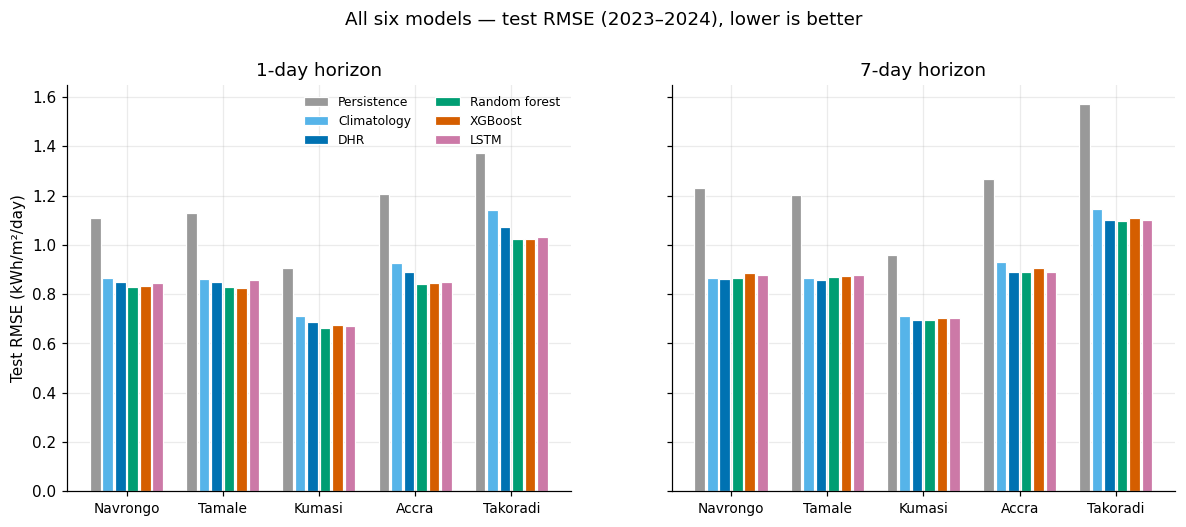

In [7]:
MODEL_COLOR = {'Persistence': '#999999', 'Climatology': '#56B4E9', 'DHR': '#0072B2',
               'Random forest': '#009E73', 'XGBoost': '#D55E00', 'LSTM': '#CC79A7'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
xs = np.arange(len(SITE_ORDER))
width = 0.13
for ax, h in zip(axes, HORIZONS):
    sub = test_met[test_met['Horizon'] == f'{h}-day']
    for i, m in enumerate(MODELS):
        vals = [sub[(sub['Site'] == SITE_LABEL[k]) & (sub['Model'] == m)]['RMSE'].iloc[0]
                for k in SITE_ORDER]
        ax.bar(xs + (i - 2.5) * width, vals, width - 0.02, color=MODEL_COLOR[m],
               label=m, edgecolor='white', linewidth=0.8)
    ax.set_xticks(xs); ax.set_xticklabels([SITE_LABEL[k] for k in SITE_ORDER], fontsize=9)
    ax.set_title(f'{h}-day horizon')
axes[0].set_ylabel('Test RMSE (kWh/m²/day)')
axes[0].legend(frameon=False, fontsize=8, ncols=2)
fig.suptitle('All six models — test RMSE (2023–2024), lower is better', y=1.02)
fig.savefig(FIGDIR / 'fig_06_1_test_rmse.png')
plt.show()

## 6.5 RQ1 inference: Diebold–Mariano tests and bootstrap skill intervals

For each site and horizon, the **validation-frozen best ML model** is compared
against DHR (primary, the strongest classical benchmark) and against climatology
(the H1 15%-reduction reference) on squared-error loss differentials
$d_t = e^2_{\mathrm{ML},t} - e^2_{\mathrm{ref},t}$:

- **One-sided Diebold–Mariano tests** (H₀: equal accuracy; Hₐ: ML more accurate)
  with the Harvey–Leybourne–Newbold small-sample correction and lag window h−1,
  Holm-adjusted within each horizon × reference family of five sites.
- **Stationarity diagnostic**: ADF test on each loss-differential series (the DM
  test assumes covariance stationarity of $d_t$).
- **Moving-block bootstrap** (Künsch, 1989) 95% intervals for the skill
  $1 - \mathrm{RMSE_{ML}}/\mathrm{RMSE_{ref}}$, block length set at the error
  series' decorrelation time (first lag where the ACF of $d_t$ falls below 1/e,
  floored at h), B = 2,000, jointly resampling the paired errors.

Saved to `dm_tests.csv`; Figure 6-2 shows the skill intervals.

    Site Horizon       Best ML   Reference   N  Skill (%) Skill 95% CI  DM t (HLN)  p (one-sided)  Block len  ADF p (d_t)  p Holm Significant (5%)
Navrongo   1-day          LSTM         DHR 730        0.4  [-1.8, 2.4]       -0.35         0.3647          1          0.0  0.3647               no
  Tamale   1-day Random forest         DHR 730        2.7   [0.9, 4.7]       -2.84         0.0023          1          0.0  0.0046              yes
  Kumasi   1-day Random forest         DHR 730        3.5   [1.9, 4.9]       -4.09         0.0000          1          0.0  0.0001              yes
   Accra   1-day Random forest         DHR 730        5.3   [3.1, 7.3]       -4.21         0.0000          1          0.0  0.0001              yes
Takoradi   1-day       XGBoost         DHR 730        4.4   [1.7, 6.9]       -3.03         0.0012          1          0.0  0.0037              yes
Navrongo   1-day          LSTM Climatology 730        2.4  [-0.3, 5.0]       -1.70         0.0450          1          

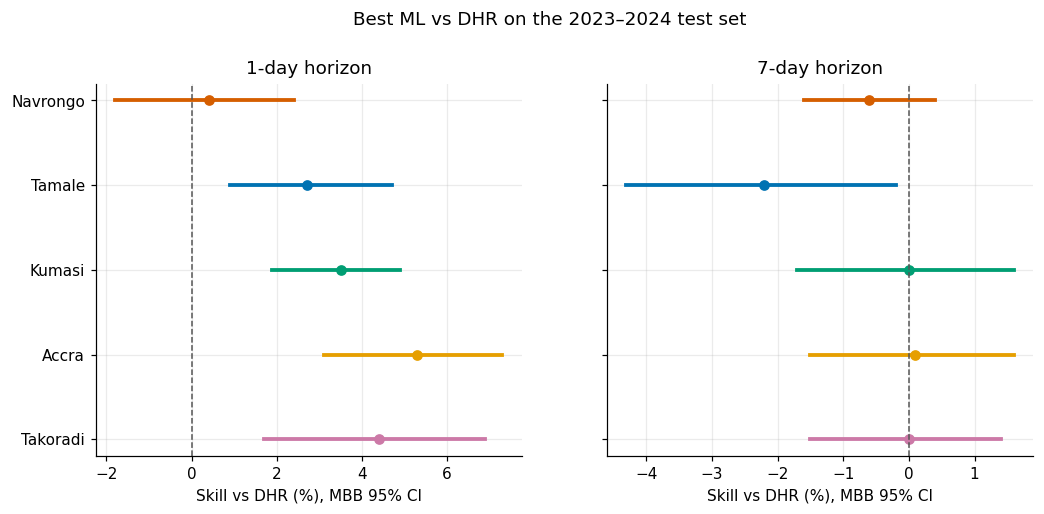

In [8]:
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf

def hln_dm(e_ml, e_ref, h):
    """One-sided HLN-corrected Diebold-Mariano test on squared-error loss.
    H0: equal accuracy; Ha: ML more accurate (mean d < 0). Returns stat, p, n."""
    d = np.asarray(e_ml, float) ** 2 - np.asarray(e_ref, float) ** 2
    n = len(d)
    dbar = d.mean()
    dc = d - dbar
    gamma = [float(dc @ dc) / n]                      # lag-0 autocovariance
    for k in range(1, h):
        gamma.append(float(dc[k:] @ dc[:-k]) / n)
    var_dbar = (gamma[0] + 2 * sum(gamma[1:])) / n
    if var_dbar <= 0:                                 # rare; fall back to lag-0 only
        var_dbar = gamma[0] / n
    dm = dbar / np.sqrt(var_dbar)
    hln = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    t_stat = dm * hln
    p = float(stats.t.cdf(t_stat, df=n - 1))          # one-sided, Ha: d < 0
    return float(t_stat), p, n

def decorr_block_len(d, h):
    """Block length ~ decorrelation time: first lag where ACF of d < 1/e."""
    a = acf(d, nlags=min(60, len(d) // 4), fft=True)
    below = np.where(a < 1 / np.e)[0]
    return int(max(h, below[0] if len(below) else 30))

def mbb_skill_ci(e_ml, e_ref, L, B=B_BOOT, seed=SEED):
    """Moving-block bootstrap 95% CI for skill = 1 - RMSE_ml/RMSE_ref,
    resampling the paired errors jointly in blocks of length L."""
    rng = np.random.default_rng(seed)
    e_ml, e_ref = np.asarray(e_ml, float), np.asarray(e_ref, float)
    n = len(e_ml)
    starts_max = n - L + 1
    n_blocks = int(np.ceil(n / L))
    sk = np.empty(B)
    for b in range(B):
        idx = np.concatenate([np.arange(s, s + L)
                              for s in rng.integers(0, starts_max, n_blocks)])[:n]
        sk[b] = 1 - np.sqrt((e_ml[idx] ** 2).mean()) / np.sqrt((e_ref[idx] ** 2).mean())
    return float(np.percentile(sk, 2.5)), float(np.percentile(sk, 97.5))

def holm(pvals):
    """Holm step-down adjusted p-values."""
    p = np.asarray(pvals, float)
    order = np.argsort(p)
    adj = np.empty_like(p)
    running = 0.0
    for rank, i in enumerate(order):
        running = max(running, (len(p) - rank) * p[i])
        adj[i] = min(1.0, running)
    return adj

dm_rows = []
for h in HORIZONS:
    for ref in ('DHR', 'Climatology'):
        fam = []
        for key in SITE_ORDER:
            p = aligned[(key, h)]
            best = BEST_ML[(key, h)]
            e_ml = (p[best] - p['actual']).to_numpy()
            e_ref = (p[ref] - p['actual']).to_numpy()
            d = e_ml ** 2 - e_ref ** 2
            t_stat, pval, n = hln_dm(e_ml, e_ref, h)
            L = decorr_block_len(d, h)
            lo, hi = mbb_skill_ci(e_ml, e_ref, L)
            skill = 1 - np.sqrt((e_ml ** 2).mean()) / np.sqrt((e_ref ** 2).mean())
            adf_p = float(adfuller(d, autolag='AIC')[1])
            fam.append({'Site': SITE_LABEL[key], 'Horizon': f'{h}-day',
                        'Best ML': best, 'Reference': ref, 'N': n,
                        'Skill (%)': round(100 * skill, 1),
                        'Skill 95% CI': f'[{100 * lo:.1f}, {100 * hi:.1f}]',
                        'DM t (HLN)': round(t_stat, 2), 'p (one-sided)': pval,
                        'Block len': L, 'ADF p (d_t)': round(adf_p, 4)})
        padj = holm([r['p (one-sided)'] for r in fam])
        for r, pa in zip(fam, padj):
            r['p Holm'] = round(float(pa), 4)
            r['p (one-sided)'] = round(r['p (one-sided)'], 4)
            r['Significant (5%)'] = 'yes' if pa < 0.05 else 'no'
        dm_rows += fam

dm = pd.DataFrame(dm_rows)
dm.to_csv(RESULTS / 'dm_tests.csv', index=False)
print(dm.to_string(index=False))

# Figure 6-2: bootstrap skill intervals vs DHR
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax, h in zip(axes, HORIZONS):
    sub = dm[(dm['Horizon'] == f'{h}-day') & (dm['Reference'] == 'DHR')]
    ys = np.arange(len(SITE_ORDER))[::-1]
    for yy, key in zip(ys, SITE_ORDER):
        r = sub[sub['Site'] == SITE_LABEL[key]].iloc[0]
        lo, hi = [float(v) for v in r['Skill 95% CI'].strip('[]').split(',')]
        ax.plot([lo, hi], [yy, yy], color=SITE_COLOR[key], lw=2.5)
        ax.plot(r['Skill (%)'], yy, 'o', color=SITE_COLOR[key], ms=6)
    ax.axvline(0, color='#555555', lw=1, ls='--')
    ax.set_yticks(ys); ax.set_yticklabels([SITE_LABEL[k] for k in SITE_ORDER])
    ax.set_title(f'{h}-day horizon')
    ax.set_xlabel('Skill vs DHR (%), MBB 95% CI')
fig.suptitle('Best ML vs DHR on the 2023–2024 test set', y=1.03)
fig.savefig(FIGDIR / 'fig_06_2_dm_skill_ci.png')
plt.show()

## 6.6 H1 adjudication

**H1**: ML models significantly outperform the classical benchmarks for 1-day-ahead
forecasts in each climatic zone (Skill > 0), and reduce RMSE by ≥ 15% relative to
day-of-year climatology. The significance leg is judged on the Holm-adjusted
one-sided DM tests; the 15% leg on the point skill versus climatology. The 7-day
horizon is reported alongside as committed in the synopsis, but H1 is stated for
1-day.

In [9]:
# H1 adjudication (stated for the 1-day horizon; 7-day reported descriptively)
print('H1: (a) DM-significant Skill > 0 vs classical benchmarks in each zone;')
print('    (b) >= 15% RMSE reduction vs day-of-year climatology.\n')
for h in HORIZONS:
    print(f'--- {h}-day horizon ---')
    sig_dhr = dm[(dm['Horizon'] == f'{h}-day') & (dm['Reference'] == 'DHR')]
    sig_cli = dm[(dm['Horizon'] == f'{h}-day') & (dm['Reference'] == 'Climatology')]
    for key in SITE_ORDER:
        lbl = SITE_LABEL[key]
        rd = sig_dhr[sig_dhr['Site'] == lbl].iloc[0]
        rc = sig_cli[sig_cli['Site'] == lbl].iloc[0]
        print(f"  {lbl:<9} best={rd['Best ML']:<13} "
              f"vs DHR: skill {rd['Skill (%)']:+5.1f}% (Holm p={rd['p Holm']:.4f}) | "
              f"vs Clim: skill {rc['Skill (%)']:+5.1f}% (Holm p={rc['p Holm']:.4f}) | "
              f"15% leg: {'MET' if rc['Skill (%)'] >= 15 else 'not met'}")
    n_sig = (sig_dhr['Significant (5%)'] == 'yes').sum()
    n_15 = (sig_cli['Skill (%)'] >= 15).sum()
    if h == 1:
        verdict = ('SUPPORTED' if (n_sig == 5 and n_15 == 5) else
                   'PARTIALLY SUPPORTED' if n_sig == 5 else 'NOT SUPPORTED')
        print(f'\n  H1 verdict (1-day): {verdict} — significance leg {n_sig}/5 sites '
              f'(vs DHR, Holm 5%); 15%-vs-climatology leg {n_15}/5 sites.\n')
    else:
        print(f'\n  7-day (descriptive): {n_sig}/5 sites significant vs DHR; '
              f'{n_15}/5 sites at >= 15% vs climatology.\n')

H1: (a) DM-significant Skill > 0 vs classical benchmarks in each zone;
    (b) >= 15% RMSE reduction vs day-of-year climatology.

--- 1-day horizon ---
  Navrongo  best=LSTM          vs DHR: skill  +0.4% (Holm p=0.3647) | vs Clim: skill  +2.4% (Holm p=0.0450) | 15% leg: not met
  Tamale    best=Random forest vs DHR: skill  +2.7% (Holm p=0.0046) | vs Clim: skill  +4.1% (Holm p=0.0049) | 15% leg: not met
  Kumasi    best=Random forest vs DHR: skill  +3.5% (Holm p=0.0001) | vs Clim: skill  +6.5% (Holm p=0.0000) | 15% leg: not met
  Accra     best=Random forest vs DHR: skill  +5.3% (Holm p=0.0001) | vs Clim: skill  +9.2% (Holm p=0.0000) | 15% leg: not met
  Takoradi  best=XGBoost       vs DHR: skill  +4.4% (Holm p=0.0037) | vs Clim: skill +10.2% (Holm p=0.0000) | 15% leg: not met

  H1 verdict (1-day): NOT SUPPORTED — significance leg 4/5 sites (vs DHR, Holm 5%); 15%-vs-climatology leg 0/5 sites.

--- 7-day horizon ---
  Navrongo  best=Random forest vs DHR: skill  -0.6% (Holm p=1.0000) | v

### Model combination check (RQ1 supplement)

Before concluding RQ1, the obvious next step, combining models, is checked on
the validation window (2021-2022, the tuning window; the test set is not
involved). If ensembling helped, it would belong in the frozen comparison;
the result below shows it does not, because the models' errors are highly
correlated. Saved to `ensemble_check.csv`.

In [10]:
# Model combination check (validation window; no test-set involvement).
# Equal-weight blends of the three ML models, and blends of the frozen best ML
# model with a train-window DHR, scored on 2021-2022. DHR is refit here on
# 2005-2020 (as in notebook 04) so the blend is a legitimate validation object.
import warnings as _w
_w.filterwarnings('ignore')
train_end = pd.Timestamp(TRAIN_END)
vp = pd.read_csv(RESULTS / 'val_predictions_ml.csv', parse_dates=['date'])

ens_rows = []
for key in SITE_ORDER:
    y = df.loc[df['site'] == key, TARGET].dropna()
    y_tr = y[y.index <= train_end]
    res = SARIMAX(y_tr, exog=fourier_X(y_tr.index), order=(1, 0, 0),
                  trend='n').fit(disp=False)
    phi = float(res.params['ar.L1'])
    Xf = fourier_X(y.index)
    mu = pd.Series(Xf.values @ res.params[Xf.columns].values, index=y.index)
    e = y - mu
    for h in HORIZONS:
        sub = val_ml[(val_ml['Horizon'] == f'{h}-day')
                     & (val_ml['Site'] == SITE_LABEL[key])]
        best_model = sub.loc[sub['RMSE'].idxmin(), 'Model']
        best_rmse = float(sub['RMSE'].min())
        wide = vp[(vp['site'] == key) & (vp['horizon'] == f'{h}-day')] \
            .pivot_table(index='date', columns='model', values='yhat').dropna()
        origin = wide.index
        target = origin + pd.Timedelta(days=h)
        ya = y.reindex(target).to_numpy()
        dhr = mu.reindex(target).to_numpy() + phi ** h * e.reindex(origin).to_numpy()
        ok = ~np.isnan(ya) & ~np.isnan(dhr)
        ya, dhr, W = ya[ok], dhr[ok], wide.to_numpy()[ok]
        blends = {'RF+XGB+LSTM (equal)': W.mean(axis=1)}
        best_col = wide.columns.get_loc(best_model)
        for w in (0.5, 0.6, 0.7):
            blends[f'{int(100*w)}% best ML + DHR'] = w * W[:, best_col] + (1 - w) * dhr
        for name, yhat in blends.items():
            rmse = float(np.sqrt(((yhat - ya) ** 2).mean()))
            ens_rows.append({'Site': SITE_LABEL[key], 'Horizon': f'{h}-day',
                             'Blend': name, 'RMSE': round(rmse, 3),
                             'Best single RMSE': best_rmse,
                             'Gain vs best single (%)':
                                 round(100 * (best_rmse - rmse) / best_rmse, 1)})
ens = pd.DataFrame(ens_rows)
ens.to_csv(RESULTS / 'ensemble_check.csv', index=False)
print('Model combination on the validation window (positive = blend better):')
summ = ens.groupby(['Horizon', 'Blend'])['Gain vs best single (%)'] \
          .agg(['median', 'min', 'max']).round(1)
print(summ, '\n')
print('Conclusion: no blend improves on the best single model at either horizon;')
print('errors are too correlated (shared weather noise), so further gains must')
print('come from new information rather than model combination.')

Model combination on the validation window (positive = blend better):
                             median  min  max
Horizon Blend                                
1-day   50% best ML + DHR      -0.6 -1.6 -0.3
        60% best ML + DHR      -0.3 -1.1 -0.1
        70% best ML + DHR      -0.1 -0.7  0.0
        RF+XGB+LSTM (equal)    -0.1 -0.4  0.4
7-day   50% best ML + DHR      -0.2 -0.5  0.4
        60% best ML + DHR      -0.1 -0.3  0.4
        70% best ML + DHR      -0.0 -0.2  0.4
        RF+XGB+LSTM (equal)    -0.2 -1.1  0.1 

Conclusion: no blend improves on the best single model at either horizon;
errors are too correlated (shared weather noise), so further gains must
come from new information rather than model combination.


## 6.7 RQ2: SHAP predictor importance and correlation testing

SHAP values (TreeExplainer, tree-path-dependent) are computed for the refit 1-day
random forest — the best-performing ML family on validation — over the 2023–2024
test rows at each site: global mean |SHAP| per feature, plus wet-season and
dry-season views. To adjudicate **H2** (cloud amount and relative humidity
associate more strongly with daily GHI than temperature, precipitation, or wind),
mean |SHAP| ranks of the five same-day meteorological drivers are combined with
Spearman rank correlations (2005–2024, Holm-adjusted within site). Saved to
`shap_importance_1day.csv`, `shap_seasonal_1day.csv`, `rq2_correlations.csv`;
Figure 6-3.

Navrongo  SHAP done (16.6s, n=730)
Tamale    SHAP done (58.4s, n=730)
Kumasi    SHAP done (16.6s, n=730)
Accra     SHAP done (96.7s, n=730)
Takoradi  SHAP done (61.6s, n=730)

H2: cloud amount & relative humidity associate more strongly with daily
GHI than temperature, precipitation, or wind.

  Navrongo  SHAP met ranking: ['PRECTOTCORR', 'RH2M', 'CLOUD_AMT', 'T2M', 'WS2M']  |rho| top-2: ['CLOUD_AMT', 'T2M']  -> NOT consistent
  Tamale    SHAP met ranking: ['PRECTOTCORR', 'CLOUD_AMT', 'RH2M', 'WS2M', 'T2M']  |rho| top-2: ['CLOUD_AMT', 'T2M']  -> NOT consistent
  Kumasi    SHAP met ranking: ['WS2M', 'PRECTOTCORR', 'T2M', 'CLOUD_AMT', 'RH2M']  |rho| top-2: ['CLOUD_AMT', 'T2M']  -> NOT consistent
  Accra     SHAP met ranking: ['WS2M', 'PRECTOTCORR', 'RH2M', 'CLOUD_AMT', 'T2M']  |rho| top-2: ['CLOUD_AMT', 'T2M']  -> NOT consistent
  Takoradi  SHAP met ranking: ['PRECTOTCORR', 'CLOUD_AMT', 'WS2M', 'RH2M', 'T2M']  |rho| top-2: ['CLOUD_AMT', 'RH2M']  -> NOT consistent

  H2 verdict: NOT SUPPO

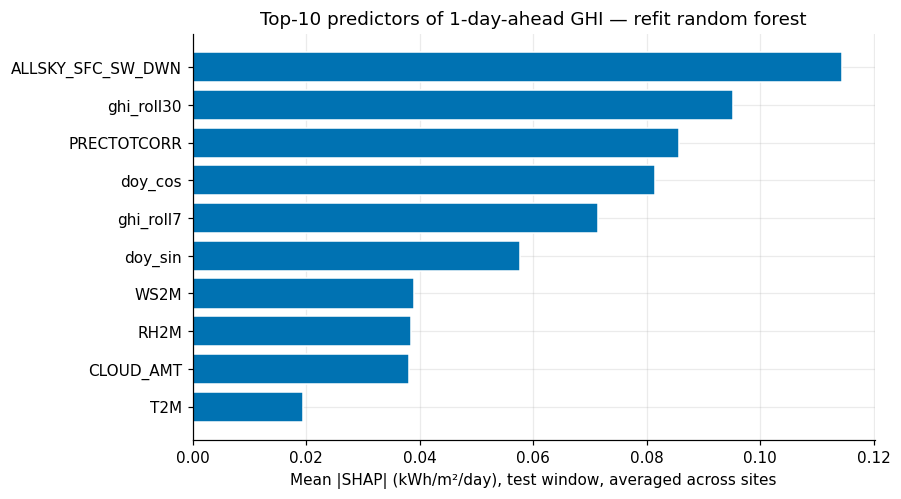

In [11]:
import shap

shap_global, shap_wet, shap_dry, shap_times = {}, {}, {}, []
for key in SITE_ORDER:
    cpath = CACHE / f'shap_{key}.pkl'
    if cpath.exists():
        with open(cpath, 'rb') as fh:
            unit = pickle.load(fh)
    else:
        # Chunked, checkpointed SHAP: the RF fit and 100-row SHAP chunks are
        # saved to a scratch dir so time-capped runs resume mid-computation.
        sdir = CACHE / f'shapwork_{key}'
        sdir.mkdir(exist_ok=True)
        sdf = df[df['site'] == key]
        X, y = make_xy(sdf, horizon=1)
        fit_m = X.index <= refit_end
        test_m = X.index > refit_end
        Xt = X[test_m].to_numpy()
        rf_file, tfile = sdir / 'rf.pkl', sdir / 'train_s.json'
        if rf_file.exists():
            with open(rf_file, 'rb') as fh:
                rf = pickle.load(fh)
            with open(tfile) as fh:
                shap_s = json.load(fh)['s']
        else:
            require_budget(90)
            t0 = time.time()
            rf = tree_estimator('Random forest',
                                BEST_PARAMS[f'{key}|Random forest|1-day'])
            rf.fit(X[fit_m], y[fit_m])                 # same seed/config as refit
            shap_s = round(time.time() - t0, 1)
            with open(rf_file, 'wb') as fh:
                pickle.dump(rf, fh)
            with open(tfile, 'w') as fh:
                json.dump({'s': shap_s}, fh)
        expl = shap.TreeExplainer(rf, feature_perturbation='tree_path_dependent')
        parts = []
        for c0 in range(0, len(Xt), 100):
            pfile = sdir / f'sv_{c0}.npy'
            if pfile.exists():
                parts.append(np.load(pfile))
                continue
            require_budget(30)
            t0 = time.time()
            svc = expl.shap_values(Xt[c0:c0 + 100], check_additivity=False)
            shap_s = round(shap_s + time.time() - t0, 1)
            with open(tfile, 'w') as fh:
                json.dump({'s': shap_s}, fh)
            np.save(pfile, svc)
            parts.append(svc)
        sv = np.vstack(parts)
        seas = sdf.loc[X.index[test_m], 'season']
        wet_m = seas.isin(WET).to_numpy()
        absv = np.abs(sv)
        unit = {'global': dict(zip(FEATURES, map(float, absv.mean(axis=0)))),
                'wet': dict(zip(FEATURES, map(float, absv[wet_m].mean(axis=0)))),
                'dry': dict(zip(FEATURES, map(float, absv[~wet_m].mean(axis=0)))),
                'shap_s': shap_s, 'n_test': int(test_m.sum())}
        with open(cpath, 'wb') as fh:
            pickle.dump(unit, fh)
    shap_global[key] = pd.Series(unit['global'])
    shap_wet[key] = pd.Series(unit['wet'])
    shap_dry[key] = pd.Series(unit['dry'])
    shap_times.append(unit.get('shap_s'))
    print(f"{SITE_LABEL[key]:<9} SHAP done ({unit.get('shap_s')}s, "
          f"n={unit.get('n_test')})")

imp_g = pd.DataFrame(shap_global)[SITE_ORDER]
imp_g.columns = [SITE_LABEL[k] for k in SITE_ORDER]
imp_g.round(4).to_csv(RESULTS / 'shap_importance_1day.csv')
seas_rows = []
for key in SITE_ORDER:
    for season, d in (('wet', shap_wet[key]), ('dry', shap_dry[key])):
        row = {'site': key, 'season': season}
        row.update({f: round(float(v), 4) for f, v in d.items()})
        seas_rows.append(row)
pd.DataFrame(seas_rows).to_csv(RESULTS / 'shap_seasonal_1day.csv', index=False)

# Spearman correlations of same-day met drivers with GHI (2005-2024), Holm per site
from scipy.stats import spearmanr
corr_rows = []
for key in SITE_ORDER:
    sdf = df[df['site'] == key]
    ps, rs = [], []
    for v in MET:
        rho, pv = spearmanr(sdf[v], sdf[TARGET])
        rs.append(rho); ps.append(pv)
    padj = holm(ps)
    for v, rho, pa in zip(MET, rs, padj):
        corr_rows.append({'Site': SITE_LABEL[key], 'Driver': v,
                          'Spearman rho': round(float(rho), 3),
                          'p Holm': float(f'{pa:.2e}'),
                          '|rho| rank': 0})
corr = pd.DataFrame(corr_rows)
corr['|rho| rank'] = corr.groupby('Site')['Spearman rho'] \
                         .transform(lambda s: s.abs().rank(ascending=False).astype(int))
corr.to_csv(RESULTS / 'rq2_correlations.csv', index=False)

# H2 adjudication: CLOUD_AMT & RH2M top-2 met drivers by mean |SHAP| and by |rho|
print('\nH2: cloud amount & relative humidity associate more strongly with daily')
print('GHI than temperature, precipitation, or wind.\n')
h2_site = []
for key in SITE_ORDER:
    lbl = SITE_LABEL[key]
    shap_rank = shap_global[key][MET].sort_values(ascending=False)
    top2_shap = set(shap_rank.index[:2])
    rho_rank = corr[corr['Site'] == lbl].set_index('Driver')['|rho| rank']
    top2_rho = set(rho_rank[rho_rank <= 2].index)
    ok = top2_shap == {'CLOUD_AMT', 'RH2M'} and top2_rho == {'CLOUD_AMT', 'RH2M'}
    h2_site.append(ok)
    print(f"  {lbl:<9} SHAP met ranking: {list(shap_rank.index)}  "
          f"|rho| top-2: {sorted(top2_rho)}  -> {'consistent' if ok else 'NOT consistent'}")
n_ok = sum(h2_site)
print(f'\n  H2 verdict: {"SUPPORTED" if n_ok == 5 else "PARTIALLY SUPPORTED" if n_ok >= 3 else "NOT SUPPORTED"} '
      f'({n_ok}/5 sites rank cloud amount and relative humidity as the two '
      f'strongest met drivers on both criteria; all correlations Holm-significant).')

# Figure 6-3: mean |SHAP| averaged across sites, top 10 features
mean_imp = imp_g.mean(axis=1).sort_values(ascending=True)
top = mean_imp.tail(10)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(range(len(top)), top.values, color='#0072B2', edgecolor='white')
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index)
ax.set_xlabel('Mean |SHAP| (kWh/m²/day), test window, averaged across sites')
ax.set_title('Top-10 predictors of 1-day-ahead GHI — refit random forest')
fig.savefig(FIGDIR / 'fig_06_3_shap_importance.png')
plt.show()

## 6.8 RQ3: seasonal and zonal error structure

Errors of the validation-frozen best ML model per site on the test window,
stratified by the site's seasonal calendar (wet = major + minor wet; dry =
harmattan + minor dry):

- **Seasonal (within site)**: one-sided moving-block-bootstrap test of
  RMSE(wet) > RMSE(dry), Holm-adjusted across the five sites per horizon; a
  June–August contrast is reported for the southern zones as the specific H3
  clause.
- **Zonal (between sites)**: pairwise RMSE differences on common target dates,
  bootstrap resampling time blocks **jointly across sites** (preserving cross-site
  dependence, per synopsis v2.2), two-sided p-values Holm-adjusted across the 10
  zone pairs.

Saved to `rq3_seasonal_tests.csv`, `rq3_zonal_tests.csv`; Figure 6-4.

Seasonal tests (wet vs dry, one-sided MBB, Holm within horizon):
    Site             Zone Horizon         Model  RMSE wet  RMSE dry  Diff  Block len  p (one-sided MBB)  RMSE JJA  RMSE rest  p Holm Significant (5%)
Navrongo   sudan_savannah   1-day          LSTM     0.858     0.827 0.031          1             0.2979     1.118      0.730  0.2979               no
  Tamale  guinea_savannah   1-day Random forest     0.869     0.767 0.102          1             0.0610     1.024      0.751  0.1220               no
  Kumasi           forest   1-day Random forest     0.749     0.523 0.225          1             0.0005     0.686      0.657  0.0025              yes
   Accra coastal_savannah   1-day Random forest     0.999     0.549 0.450          1             0.0005     0.836      0.843  0.0025              yes
Takoradi          coastal   1-day       XGBoost     1.202     0.701 0.502          1             0.0005     1.041      1.018  0.0025              yes
Navrongo   sudan_savannah   7-day R

Zonal tests (pairwise RMSE, joint-block MBB, Holm within horizon):
Horizon           Zone A           Zone B  RMSE A  RMSE B   Diff  Block len  p (two-sided MBB)  p Holm Significant (5%)
  1-day   sudan_savannah  guinea_savannah   0.845   0.828  0.017          1             0.5287    1.00               no
  1-day   sudan_savannah           forest   0.845   0.664  0.181          1             0.0010    0.01              yes
  1-day   sudan_savannah coastal_savannah   0.845   0.841  0.003          1             0.9185    1.00               no
  1-day   sudan_savannah          coastal   0.845   1.024 -0.179          1             0.0010    0.01              yes
  1-day  guinea_savannah           forest   0.828   0.664  0.164          1             0.0010    0.01              yes
  1-day  guinea_savannah coastal_savannah   0.828   0.841 -0.013          1             0.7286    1.00               no
  1-day  guinea_savannah          coastal   0.828   1.024 -0.196          1             0.001

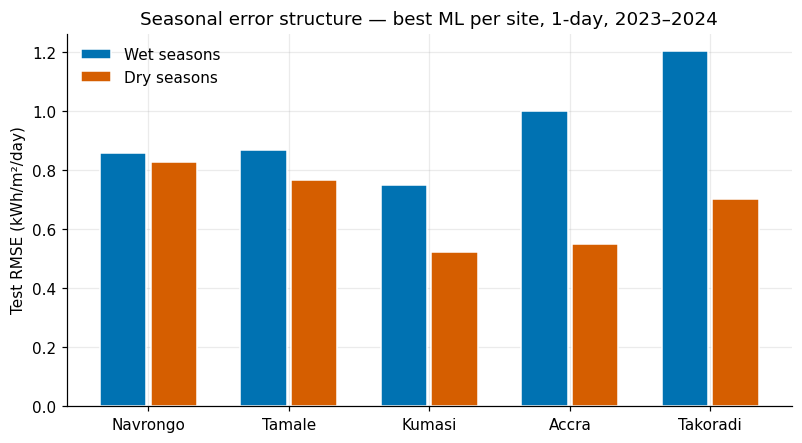

In [12]:
def mbb_stat_p(x_a, x_b, stat_fn, L, B=B_BOOT, seed=SEED, one_sided=True):
    """MBB resampling of paired series; returns observed stat and bootstrap p.
    stat_fn maps (a, b) index-resampled arrays to a scalar (e.g. RMSE diff).
    one_sided: p = P*(stat <= 0) for Ha: stat > 0; else two-sided."""
    rng = np.random.default_rng(seed)
    n = len(x_a)
    starts_max = n - L + 1
    n_blocks = int(np.ceil(n / L))
    obs = stat_fn(np.arange(n))
    boots = np.empty(B)
    for b in range(B):
        idx = np.concatenate([np.arange(s, s + L)
                              for s in rng.integers(0, starts_max, n_blocks)])[:n]
        boots[b] = stat_fn(idx)
    if one_sided:
        p = (1 + np.sum(boots <= 0)) / (B + 1)
    else:
        p = 2 * min((1 + np.sum(boots <= 0)) / (B + 1),
                    (1 + np.sum(boots >= 0)) / (B + 1))
    return float(obs), float(min(p, 1.0))

# ---- Seasonal: RMSE(wet) > RMSE(dry) per site & horizon (one-sided MBB) ----
seas_rows = []
for h in HORIZONS:
    fam = []
    for key in SITE_ORDER:
        p = aligned[(key, h)]
        best = BEST_ML[(key, h)]
        err = (p[best] - p['actual']).to_numpy()
        seas = df.loc[df['site'] == key].loc[p.index, 'season']
        wet = seas.isin(WET).to_numpy()
        L = decorr_block_len(err ** 2, h)

        def stat_fn(idx, err=err, wet=wet):
            e, w = err[idx], wet[idx]
            if w.sum() < 30 or (~w).sum() < 30:
                return 0.0
            return float(np.sqrt((e[w] ** 2).mean()) - np.sqrt((e[~w] ** 2).mean()))

        obs, pv = mbb_stat_p(err, wet, stat_fn, L, one_sided=True)
        # southern-zone June-August clause (descriptive)
        jja = p.index.month.isin([6, 7, 8])
        rmse_jja = float(np.sqrt((err[jja] ** 2).mean()))
        rmse_rest = float(np.sqrt((err[~jja] ** 2).mean()))
        fam.append({'Site': SITE_LABEL[key], 'Zone': ZONE[key],
                    'Horizon': f'{h}-day', 'Model': best,
                    'RMSE wet': round(float(np.sqrt((err[wet] ** 2).mean())), 3),
                    'RMSE dry': round(float(np.sqrt((err[~wet] ** 2).mean())), 3),
                    'Diff': round(obs, 3), 'Block len': L,
                    'p (one-sided MBB)': round(pv, 4),
                    'RMSE JJA': round(rmse_jja, 3),
                    'RMSE rest': round(rmse_rest, 3)})
    padj = holm([r['p (one-sided MBB)'] for r in fam])
    for r, pa in zip(fam, padj):
        r['p Holm'] = round(float(pa), 4)
        r['Significant (5%)'] = 'yes' if pa < 0.05 else 'no'
    seas_rows += fam
rq3_seas = pd.DataFrame(seas_rows)
rq3_seas.to_csv(RESULTS / 'rq3_seasonal_tests.csv', index=False)
print('Seasonal tests (wet vs dry, one-sided MBB, Holm within horizon):')
print(rq3_seas.to_string(index=False), '\n')

# ---- Zonal: pairwise RMSE differences, joint time-block resampling ----------
from itertools import combinations
zone_rows = []
for h in HORIZONS:
    common = None
    errs = {}
    for key in SITE_ORDER:
        p = aligned[(key, h)]
        e = (p[BEST_ML[(key, h)]] - p['actual'])
        errs[key] = e
        common = e.index if common is None else common.intersection(e.index)
    E = np.column_stack([errs[k].reindex(common).to_numpy() for k in SITE_ORDER])
    L = int(max(decorr_block_len(E[:, i] ** 2, h) for i in range(5)))
    fam = []
    for i, j in combinations(range(5), 2):
        def stat_fn(idx, i=i, j=j):
            return float(np.sqrt((E[idx, i] ** 2).mean())
                         - np.sqrt((E[idx, j] ** 2).mean()))
        obs, pv = mbb_stat_p(E[:, i], E[:, j], stat_fn, L, one_sided=False)
        fam.append({'Horizon': f'{h}-day',
                    'Zone A': ZONE[SITE_ORDER[i]], 'Zone B': ZONE[SITE_ORDER[j]],
                    'RMSE A': round(float(np.sqrt((E[:, i] ** 2).mean())), 3),
                    'RMSE B': round(float(np.sqrt((E[:, j] ** 2).mean())), 3),
                    'Diff': round(obs, 3), 'Block len': L,
                    'p (two-sided MBB)': round(pv, 4)})
    padj = holm([r['p (two-sided MBB)'] for r in fam])
    for r, pa in zip(fam, padj):
        r['p Holm'] = round(float(pa), 4)
        r['Significant (5%)'] = 'yes' if pa < 0.05 else 'no'
    zone_rows += fam
rq3_zone = pd.DataFrame(zone_rows)
rq3_zone.to_csv(RESULTS / 'rq3_zonal_tests.csv', index=False)
print('Zonal tests (pairwise RMSE, joint-block MBB, Holm within horizon):')
print(rq3_zone.to_string(index=False), '\n')

# ---- H3 adjudication --------------------------------------------------------
south = {'accra', 'takoradi'}
s1 = rq3_seas[rq3_seas['Horizon'] == '1-day']
n_sig = (s1['Significant (5%)'] == 'yes').sum()
worst = s1.loc[s1['Diff'].idxmax(), 'Site']
south_jja = all(
    s1[s1['Site'] == SITE_LABEL[k]].iloc[0]['RMSE JJA']
    > s1[s1['Site'] == SITE_LABEL[k]].iloc[0]['RMSE rest'] for k in south)
print('H3: RMSE differs between wet and dry seasons, largest degradation in the')
print('southern zones during June-August.')
print(f'  1-day: wet > dry Holm-significant at {n_sig}/5 sites; '
      f'largest wet-dry gap: {worst}; '
      f'southern JJA degradation clause: {"holds" if south_jja else "does NOT hold"}.')
verdict = ('SUPPORTED' if n_sig >= 4 and south_jja else
           'PARTIALLY SUPPORTED' if n_sig >= 2 else 'NOT SUPPORTED')
print(f'  H3 verdict (1-day): {verdict}')

# Figure 6-4: wet vs dry RMSE per site (1-day, best ML)
fig, ax = plt.subplots(figsize=(8.5, 4.4))
xs = np.arange(len(SITE_ORDER))
for i, (col, colr, lab) in enumerate((('RMSE wet', '#0072B2', 'Wet seasons'),
                                      ('RMSE dry', '#D55E00', 'Dry seasons'))):
    vals = [s1[s1['Site'] == SITE_LABEL[k]].iloc[0][col] for k in SITE_ORDER]
    ax.bar(xs + (i - 0.5) * 0.36, vals, 0.33, color=colr, label=lab,
           edgecolor='white')
ax.set_xticks(xs); ax.set_xticklabels([SITE_LABEL[k] for k in SITE_ORDER])
ax.set_ylabel('Test RMSE (kWh/m²/day)')
ax.set_title('Seasonal error structure — best ML per site, 1-day, 2023–2024')
ax.legend(frameon=False)
fig.savefig(FIGDIR / 'fig_06_4_seasonal_rmse.png')
plt.show()

## 6.9 Hypothesis verdicts and what comes next

The committed tests return three verdicts:

- **H1 (RQ1): not supported.** At 1 day the frozen best ML model beats DHR with
  Holm-adjusted DM significance at 4/5 sites (skill +2.7% to +5.3%; Navrongo
  +0.4% n.s.) and beats climatology significantly at 5/5, but no site reaches
  the pre-registered 15% reduction vs. climatology (max +10.2%, Takoradi). At 7
  days nothing separates from DHR. The model-combination check closes the
  obvious rejoinder: no ensemble or DHR blend improves on the best single model
  (median -0.1% to -0.6%), so the ceiling is informational, not architectural.
- **H2 (RQ2): not supported, with an instructive mechanism.** Marginally, cloud
  amount is the strongest correlate of GHI everywhere (Spearman rho -.44 to
  -.69); conditionally (SHAP), irradiance history absorbs that signal and
  same-day met drivers rank low. Cloudiness drives GHI, but it adds little once
  yesterday's irradiance is known.
- **H3 (RQ3): partially supported.** Wet-season RMSE is significantly worse at
  Kumasi, Accra, and Takoradi (gaps to +0.50 kWh/m²/day) at both horizons, not
  in the north; the zonal ordering (forest easiest, coast hardest) is stable
  and significant; the specific June-August clause fails marginally at Accra.

Notebook 07 carries the same 20-year record into the reliability-constrained
sizing simulation (RQ4/H4), where the zone differences that limit forecasting
become the decision variable.